# Drug Addiction and Educational Patterns Across Malaysian States

## Research Question

**How did the number and educational composition of recorded drug addicts vary across Malaysian states from 2019 to 2022, was this variation associated with state-level school completion rates, and how accurately could the following year's number of recorded drug addicts be predicted using historical state-level addiction and education indicators?**

## Background

A Malaysian news report highlighted an increase in drug-related supply and possession offences. Motivated by this issue, this notebook examines the geographical and educational distribution of recorded drug addicts using Malaysian administrative data, and then tests whether historical state-level indicators can predict the following year's recorded total.

## Important Scope

- The drug dataset contains administrative records of **recorded drug addicts**.
- The records do not represent all people who use drugs.
- The records do not represent drug offences, arrests, prosecutions, convictions, or individual risk.
- Raw state totals are not population-adjusted prevalence rates.
- The school dataset contains state-level completion indicators, not the personal education histories of the recorded addicts.
- Completion values above 100 are flagged and retained unless official source metadata proves that they are erroneous; no explanation for them is invented here.
- Any relationship identified after combining the datasets is an aggregate, state-level association and does not establish individual-level causation.
- The supervised regression part predicts recorded totals using **only information available in the preceding year**; a predictive association does not imply that education indicators cause changes in recorded addiction.

## 1. Import Libraries and Configure the Notebook

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "RQ2_Drug_Education.ipynb").exists():
    ROOT_DIR = NOTEBOOK_DIR.parent
else:
    ROOT_DIR = NOTEBOOK_DIR

DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"
FIGURE_DIR = OUTPUT_DIR
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

DRUG_FILE = DATA_DIR / "drug_addicts_education.csv"
SCHOOL_FILE = DATA_DIR / "completion_school_state.csv"

print("Working directory:", Path.cwd())
print("Expected drug file:", DRUG_FILE.resolve())
print("Expected school file:", SCHOOL_FILE.resolve())

Working directory: C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\notebook
Expected drug file: C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\data\drug_addicts_education.csv
Expected school file: C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\data\completion_school_state.csv


## 2. Load the Datasets

The files `drug_addicts_education.csv` and `completion_school_state.csv` are read from the repository `data/` directory using paths relative to this notebook.

In [2]:
for file_path in [DRUG_FILE, SCHOOL_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing {file_path.name}. Place it in the same folder as this notebook."
        )

drug_raw = pd.read_csv(DRUG_FILE)
school_raw = pd.read_csv(SCHOOL_FILE)

print("Drug dataset shape:", drug_raw.shape)
print("School dataset shape:", school_raw.shape)

display(drug_raw.head())
display(school_raw.head())

Drug dataset shape: (792, 4)
School dataset shape: (1071, 5)


,date,state,education,addicts
0,2020-01-01,Malaysia,total,"20,643.00"
1,2021-01-01,Malaysia,total,"18,205.00"
2,2023-01-01,Malaysia,total,"24,921.00"
3,2020-01-01,Malaysia,total,"20,643.00"
4,2019-01-01,Malaysia,total,"26,080.00"


,state,stage,sex,date,completion
0,Malaysia,primary,both,2016-01-01,98.37
1,Malaysia,primary,both,2017-01-01,98.07
2,Malaysia,primary,both,2018-01-01,97.67
3,Malaysia,primary,both,2019-01-01,98.00
4,Malaysia,primary,both,2020-01-01,98.40


## 3. Initial Data Inspection

In [3]:
print("DRUG DATASET")
drug_raw.info()
print("SCHOOL DATASET")
school_raw.info()

quality_summary = pd.DataFrame({
    "drug_missing": drug_raw.isna().sum(),
    "school_missing": school_raw.isna().sum()
})
display(quality_summary)

print("Exact duplicate rows in drug data:", drug_raw.duplicated().sum())
print("Exact duplicate rows in school data:", school_raw.duplicated().sum())

DRUG DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       792 non-null    object 
 1   state      792 non-null    object 
 2   education  792 non-null    object 
 3   addicts    773 non-null    float64
dtypes: float64(1), object(3)
memory usage: 24.9+ KB
SCHOOL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       1071 non-null   object 
 1   stage       1071 non-null   object 
 2   sex         1071 non-null   object 
 3   date        1071 non-null   object 
 4   completion  1071 non-null   float64
dtypes: float64(1), object(4)
memory usage: 42.0+ KB


,drug_missing,school_missing
addicts,19.00,NaN
completion,NaN,0.00
date,0.00,0.00
education,0.00,NaN
sex,NaN,0.00
stage,NaN,0.00
state,0.00,0.00


Exact duplicate rows in drug data: 9
Exact duplicate rows in school data: 0


## 4. Data Cleaning

Cleaning decisions:

1. Remove exact duplicate rows to prevent double counting.
2. Convert date fields to proper datetime values and derive year.
3. Convert `addicts` and `completion` to numeric values.
4. Preserve unavailable records as `NaN` rather than assuming that blank means zero.
5. Standardise text fields by stripping surrounding whitespace.

In [4]:
drug = drug_raw.drop_duplicates().copy()
school = school_raw.drop_duplicates().copy()

for column in ["state", "education"]:
    drug[column] = drug[column].astype("string").str.strip()

for column in ["state", "stage", "sex"]:
    school[column] = school[column].astype("string").str.strip()

drug["date"] = pd.to_datetime(drug["date"], errors="coerce")
school["date"] = pd.to_datetime(school["date"], errors="coerce")
drug["addicts"] = pd.to_numeric(drug["addicts"], errors="coerce")
school["completion"] = pd.to_numeric(school["completion"], errors="coerce")

drug["year"] = drug["date"].dt.year.astype("Int64")
school["year"] = school["date"].dt.year.astype("Int64")

print("Drug duplicates removed:", len(drug_raw) - len(drug))
print("School duplicates removed:", len(school_raw) - len(school))
print("Drug missing addicts:", drug["addicts"].isna().sum())
print("School missing completion:", school["completion"].isna().sum())

Drug duplicates removed: 9
School duplicates removed: 0
Drug missing addicts: 19
School missing completion: 0


## 5. Exploratory Data Analysis

In [5]:
print("Drug years:", sorted(drug["year"].dropna().unique().tolist()))
print("School years:", sorted(school["year"].dropna().unique().tolist()))
print("Drug states:", drug["state"].nunique())
print("School states:", school["state"].nunique())
print("Drug education categories:")
print(sorted(drug["education"].dropna().unique().tolist()))
print("School stages:")
print(sorted(school["stage"].dropna().unique().tolist()))
print("School sex categories:")
print(sorted(school["sex"].dropna().unique().tolist()))

display(drug["addicts"].describe())
display(school["completion"].describe())

Drug years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
School years: [2016, 2017, 2018, 2019, 2020, 2021, 2022]
Drug states: 17
School states: 17
Drug education categories:
['diploma', 'none', 'others', 'pmr', 'primary', 'spm', 'stpm', 'tertiary', 'total']
School stages:
['primary', 'secondary_lower', 'secondary_upper']
School sex categories:
['both', 'female', 'male']


count      764.00
mean       744.80
std      2,672.64
min          0.00
25%         16.00
50%         74.00
75%        536.75
max     30,844.00
Name: addicts, dtype: float64

count   1,071.00
mean       97.66
std         3.82
min        73.90
25%        96.10
50%        98.00
75%        99.51
max       112.90
Name: completion, dtype: float64

### Completion Values Above 100

Values above 100 are flagged for inspection rather than automatically removed. They may reflect a gross completion measure, over-age learners, repeaters, migration, or denominator estimation differences. The source metadata should be consulted before treating them as errors.

In [6]:
completion_above_100 = school.loc[
    school["completion"] > 100,
    ["state", "stage", "sex", "year", "completion"]
].sort_values("completion", ascending=False)

print("Number of completion observations above 100:", len(completion_above_100))
display(completion_above_100.head(15))

Number of completion observations above 100: 183


,state,stage,sex,year,completion
221,Kelantan,secondary_lower,female,2020,112.90
222,Kelantan,secondary_lower,female,2021,112.90
1036,W.P. Putrajaya,secondary_lower,female,2016,111.72
241,Kelantan,secondary_upper,female,2019,111.70
215,Kelantan,secondary_lower,both,2021,111.70
1057,W.P. Putrajaya,secondary_upper,female,2016,110.95
229,Kelantan,secondary_lower,male,2021,110.50
1029,W.P. Putrajaya,secondary_lower,both,2016,110.34
214,Kelantan,secondary_lower,both,2020,109.90
1037,W.P. Putrajaya,secondary_lower,female,2017,109.70


## 6. Restrict Analysis to the Common Period, 2019 to 2022

State-level records in the drug dataset begin in 2019, and the school completion dataset ends in 2022. The state-level analysis is therefore restricted to **2019 to 2022** (`START_YEAR = 2019`, `END_YEAR = 2022`).

In [7]:
START_YEAR = 2019
END_YEAR = 2022

drug_period = drug[drug["year"].between(START_YEAR, END_YEAR)].copy()
school_period = school[school["year"].between(START_YEAR, END_YEAR)].copy()

print("Drug observations in common period:", len(drug_period))
print("School observations in common period:", len(school_period))

Drug observations in common period: 603
School observations in common period: 612


## 7. Prepare State-Level Total Records

The `total` rows are used directly. They are not added to the component education categories, which would double count the same records. The national `Malaysia` record is excluded from state comparisons.

In [8]:
state_totals = (
    drug_period.loc[
        (drug_period["state"] != "Malaysia") &
        (drug_period["education"] == "total"),
        ["state", "year", "addicts"]
    ]
    .rename(columns={"addicts": "total_addicts"})
    .copy()
)

key_duplicates = state_totals.duplicated(["state", "year"]).sum()
print("Duplicate state-year keys:", key_duplicates)
if key_duplicates:
    display(state_totals[state_totals.duplicated(["state", "year"], keep=False)])

state_totals = state_totals.drop_duplicates(["state", "year"])
display(state_totals.head())

Duplicate state-year keys: 0


,state,year,total_addicts
8,Johor,2021,"2,081.00"
9,Johor,2022,"2,674.00"
11,Johor,2019,"2,371.00"
12,Johor,2020,"2,564.00"
13,Kedah,2019,"3,582.00"


## 8. Quantitative Analysis 1: State Summary Statistics

In [9]:
state_summary = (
    state_totals.groupby("state", as_index=False)
    .agg(
        total_recorded_addicts=("total_addicts", "sum"),
        average_annual_addicts=("total_addicts", "mean"),
        minimum_annual_addicts=("total_addicts", "min"),
        maximum_annual_addicts=("total_addicts", "max"),
        years_available=("year", "nunique")
    )
    .sort_values("total_recorded_addicts", ascending=False)
)

display(state_summary)

,state,total_recorded_addicts,average_annual_addicts,minimum_annual_addicts,maximum_annual_addicts,years_available
1,Kedah,"10,874.00","2,718.50","2,196.00","3,582.00",4
2,Kelantan,"9,775.00","2,443.75","2,167.00","2,998.00",4
0,Johor,"9,690.00","2,422.50","2,081.00","2,674.00",4
12,Terengganu,"8,633.00","2,158.25","2,033.00","2,240.00",4
11,Selangor,"8,613.00","2,153.25","1,712.00","2,553.00",4
8,Pulau Pinang,"8,225.00","2,056.25","1,358.00","2,893.00",4
6,Perak,"7,880.00","1,970.00","1,637.00","2,376.00",4
5,Pahang,"5,436.00","1,359.00",977.00,"1,672.00",4
13,W.P. Kuala Lumpur,"3,884.00",971.00,857.00,"1,024.00",4
9,Sabah,"3,755.00",938.75,644.00,"1,574.00",4


## 9. Feature Engineering and Analysis 2: State Share of Recorded Addicts

`state_share_pct` measures a state's share of the total records across the available states in a given year. It is not a population-adjusted addiction rate.

In [10]:
state_totals["all_states_total"] = (
    state_totals.groupby("year")["total_addicts"].transform("sum")
)
state_totals["state_share_pct"] = (
    state_totals["total_addicts"] / state_totals["all_states_total"] * 100
)

latest_year = int(state_totals["year"].max())
latest_state_data = (
    state_totals[state_totals["year"] == latest_year]
    .sort_values("total_addicts", ascending=False)
)

display(latest_state_data)

,state,year,total_addicts,all_states_total,state_share_pct
16,Kedah,2022,"2,724.00","23,517.00",11.58
9,Johor,2022,"2,674.00","23,517.00",11.37
64,Selangor,2022,"2,553.00","23,517.00",10.86
39,Perak,2022,"2,376.00","23,517.00",10.10
19,Kelantan,2022,"2,339.00","23,517.00",9.95
49,Pulau Pinang,2022,"2,247.00","23,517.00",9.55
69,Terengganu,2022,"2,237.00","23,517.00",9.51
34,Pahang,2022,"1,392.00","23,517.00",5.92
59,Sarawak,2022,"1,215.00","23,517.00",5.17
74,W.P. Kuala Lumpur,2022,980.00,"23,517.00",4.17


## 10. Visualisation 1: Recorded Addicts by State

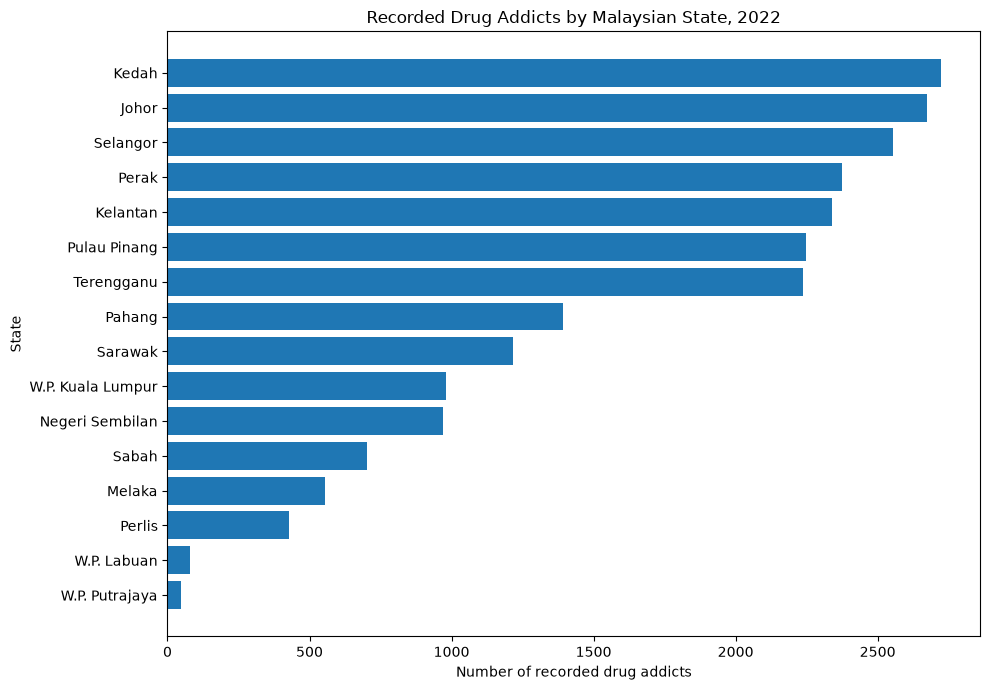

In [11]:
plot_data = latest_state_data.sort_values("total_addicts")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data["state"], plot_data["total_addicts"])
ax.set_title(f"Recorded Drug Addicts by Malaysian State, {latest_year}")
ax.set_xlabel("Number of recorded drug addicts")
ax.set_ylabel("State")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "recorded_addicts_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

**Findings:** In 2022, the highest recorded counts were Kedah (2,724), Johor (2,674) and Selangor (2,553), while the lowest were Perlis (429), W.P. Labuan (78) and W.P. Putrajaya (46). These are raw administrative counts, not prevalence rates: they are influenced by population size, treatment access, reporting, and administrative coverage, and they do not indicate individual risk.

## 11. Prepare Education-Specific Records

In [12]:
education_data = drug_period.loc[
    (drug_period["state"] != "Malaysia") &
    (drug_period["education"] != "total")
].copy()

education_data["state_year_education_sum"] = (
    education_data.groupby(["state", "year"])["addicts"].transform("sum")
)
education_data["education_share_pct"] = (
    education_data["addicts"] /
    education_data["state_year_education_sum"] * 100
)

display(education_data.head(10))

,date,state,education,addicts,year,state_year_education_sum,education_share_pct
96,2021-01-01,Johor,none,113.00,2021,"2,081.00",5.43
97,2022-01-01,Johor,none,170.00,2022,"2,674.00",6.36
99,2019-01-01,Johor,none,442.00,2019,"2,371.00",18.64
100,2020-01-01,Johor,none,573.00,2020,"2,564.00",22.35
101,2019-01-01,Kedah,none,722.00,2019,"3,582.00",20.16
102,2020-01-01,Kedah,none,248.00,2020,"2,372.00",10.46
103,2021-01-01,Kedah,none,432.00,2021,"2,196.00",19.67
104,2022-01-01,Kedah,none,111.00,2022,"2,724.00",4.07
106,2021-01-01,Kelantan,none,29.00,2021,"2,167.00",1.34
107,2022-01-01,Kelantan,none,26.00,2022,"2,339.00",1.11


## 12. Quantitative Analysis 3: Overall Educational Composition

In [13]:
education_summary = (
    education_data.groupby("education", as_index=False)["addicts"]
    .sum(min_count=1)
    .rename(columns={"addicts": "recorded_addicts"})
    .sort_values("recorded_addicts", ascending=False)
)
education_summary["share_pct"] = (
    education_summary["recorded_addicts"] /
    education_summary["recorded_addicts"].sum() * 100
)

display(education_summary)

,education,recorded_addicts,share_pct
5,spm,"34,592.00",39.11
3,pmr,"30,746.00",34.76
4,primary,"8,375.00",9.47
1,none,"8,128.00",9.19
2,others,"3,074.00",3.48
0,diploma,"2,445.00",2.76
6,stpm,576.00,0.65
7,tertiary,509.00,0.58


## 13. Visualisation 2: Educational Composition

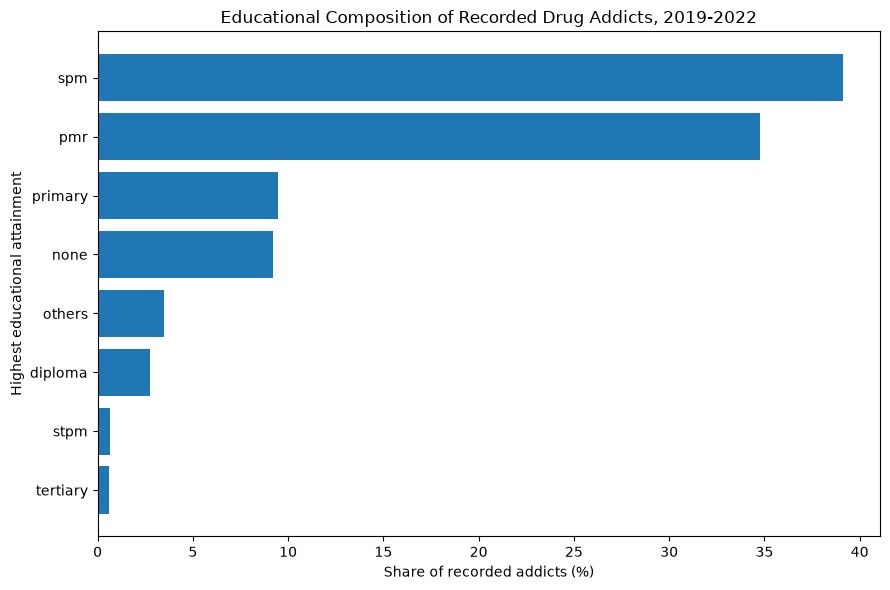

In [14]:
plot_education = education_summary.sort_values("share_pct")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_education["education"], plot_education["share_pct"])
ax.set_title(
    f"Educational Composition of Recorded Drug Addicts, {START_YEAR}-{END_YEAR}"
)
ax.set_xlabel("Share of recorded addicts (%)")
ax.set_ylabel("Highest educational attainment")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "education_composition.png", dpi=300, bbox_inches="tight")
plt.show()

**Findings:** Across 2019-2022, SPM is the most common education category among recorded addicts (39.1%), followed by PMR (34.8%); together they account for about 73.9% of records. The remaining categories are primary (9.5%), none (9.2%), others (3.5%), diploma (2.8%), STPM (0.7%) and tertiary (0.6%). This does not show that people in the larger categories have a higher addiction risk because the population size of each education group is unavailable.

## 14. Quantitative Analysis 4: Dominant Education Category by State and Year

In [15]:
dominant_education = (
    education_data.dropna(subset=["addicts"])
    .sort_values(
        ["state", "year", "education_share_pct"],
        ascending=[True, True, False]
    )
    .groupby(["state", "year"], as_index=False)
    .first()[
        ["state", "year", "education", "addicts", "education_share_pct"]
    ]
    .rename(columns={"education": "dominant_education_category"})
)

display(dominant_education.head(25))

,state,year,dominant_education_category,addicts,education_share_pct
0,Johor,2019,spm,824.00,34.75
1,Johor,2020,spm,887.00,34.59
2,Johor,2021,spm,814.00,39.12
3,Johor,2022,spm,"1,055.00",39.45
4,Kedah,2019,spm,"1,190.00",33.22
5,Kedah,2020,spm,949.00,40.01
6,Kedah,2021,spm,851.00,38.75
7,Kedah,2022,spm,"1,138.00",41.78
8,Kelantan,2019,spm,"1,213.00",40.46
9,Kelantan,2020,spm,957.00,42.14


## 15. Quantitative Analysis 5 and Visualisation 3: State-Education Heatmap

education,diploma,none,others,pmr,primary,spm,stpm,tertiary
state,,,,,,,,
Johor,2.51,6.36,3.81,35.00,11.93,39.45,0.56,0.37
Kedah,1.76,4.07,3.89,37.08,10.54,41.78,0.51,0.37
Kelantan,2.22,1.11,3.42,42.33,9.11,39.72,1.62,0.47
Melaka,3.60,1.80,5.23,37.66,7.57,42.88,0.54,0.72
Negeri Sembilan,4.02,2.48,6.40,34.06,11.46,40.25,0.72,0.62
Pahang,3.16,1.87,3.74,35.49,10.13,44.40,0.65,0.57
Perak,1.89,5.98,3.45,37.29,12.04,38.51,0.21,0.63
Perlis,2.80,0.70,2.56,40.79,6.76,45.92,0.23,0.23
Pulau Pinang,1.78,13.17,1.96,40.77,6.85,34.49,0.49,0.49


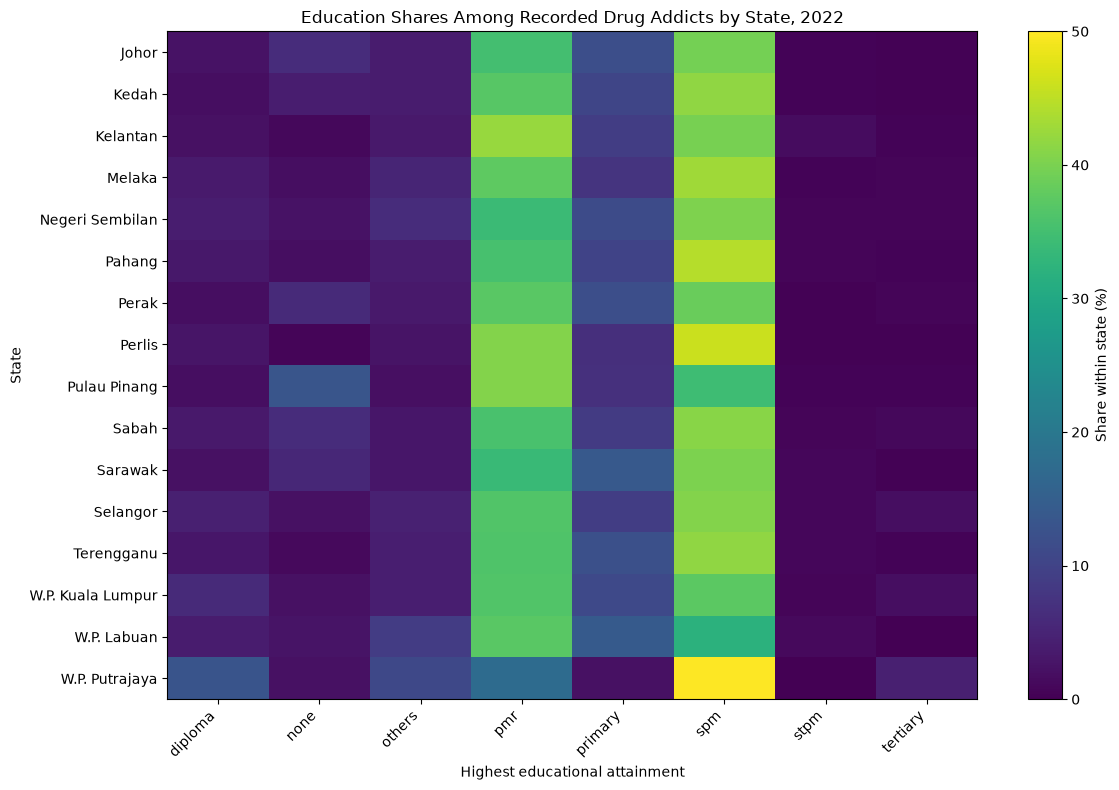

In [16]:
latest_education = education_data[education_data["year"] == latest_year].copy()

education_pivot = latest_education.pivot_table(
    index="state",
    columns="education",
    values="education_share_pct",
    aggfunc="sum"
).sort_index()

display(education_pivot.round(2))

heatmap_data = education_pivot.fillna(0)
fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(heatmap_data.values, aspect="auto")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title(f"Education Shares Among Recorded Drug Addicts by State, {latest_year}")
ax.set_xlabel("Highest educational attainment")
ax.set_ylabel("State")
colour_bar = fig.colorbar(image, ax=ax)
colour_bar.set_label("Share within state (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "state_education_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Quantitative Analysis 6: Year-on-Year Change

In [17]:
state_trends = state_totals.sort_values(["state", "year"]).copy()
state_trends["year_on_year_change_pct"] = (
    state_trends.groupby("state")["total_addicts"].pct_change() * 100
)

largest_increases = (
    state_trends.dropna(subset=["year_on_year_change_pct"])
    .sort_values("year_on_year_change_pct", ascending=False)
    .head(10)
)

largest_decreases = (
    state_trends.dropna(subset=["year_on_year_change_pct"])
    .sort_values("year_on_year_change_pct")
    .head(10)
)

print("Largest year-on-year increases")
display(largest_increases[["state", "year", "total_addicts", "year_on_year_change_pct"]])
print("Largest year-on-year decreases")
display(largest_decreases[["state", "year", "total_addicts", "year_on_year_change_pct"]])

Largest year-on-year increases


,state,year,total_addicts,year_on_year_change_pct
44,Perlis,2022,429.00,101.41
83,W.P. Putrajaya,2021,71.00,91.89
59,Sarawak,2022,"1,215.00",70.65
49,Pulau Pinang,2022,"2,247.00",65.46
79,W.P. Labuan,2022,78.00,62.50
39,Perak,2022,"2,376.00",45.14
34,Pahang,2022,"1,392.00",42.48
29,Negeri Sembilan,2022,969.00,36.67
64,Selangor,2022,"2,553.00",30.06
9,Johor,2022,"2,674.00",28.50


Largest year-on-year decreases


,state,year,total_addicts,year_on_year_change_pct
57,Sabah,2020,834.00,-47.01
78,W.P. Labuan,2021,48.00,-46.67
52,Pulau Pinang,2020,"1,727.00",-40.30
82,W.P. Labuan,2020,90.00,-35.25
84,W.P. Putrajaya,2022,46.00,-35.21
23,Melaka,2021,539.00,-34.98
32,Negeri Sembilan,2020,812.00,-34.73
14,Kedah,2020,"2,372.00",-33.78
33,Pahang,2021,977.00,-29.96
67,Selangor,2020,"1,712.00",-28.22


## 17. Visualisation 4: Trends for the Five Highest-Count States

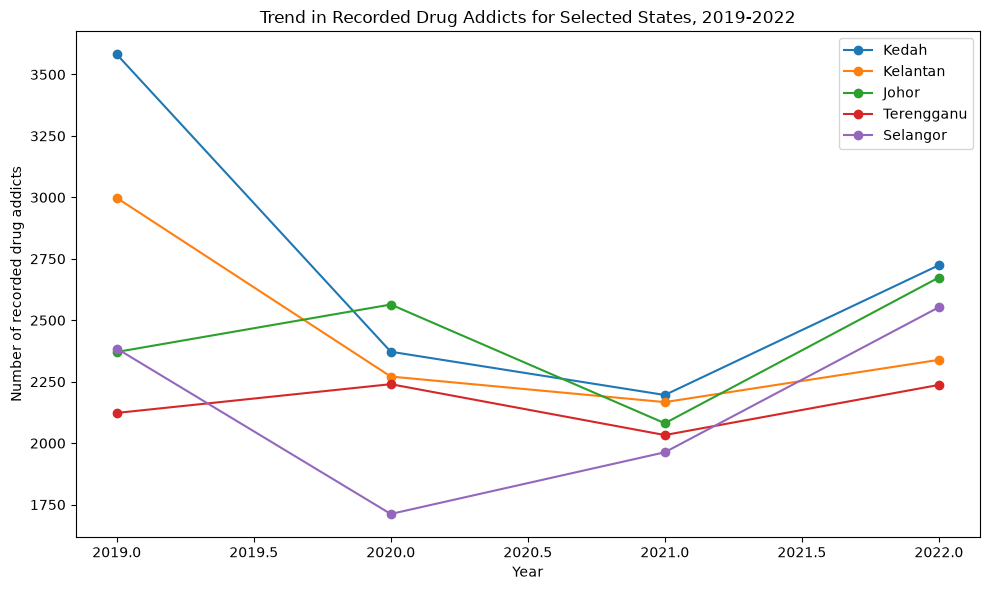

In [18]:
top_five_states = state_summary.head(5)["state"].tolist()
top_state_trends = state_totals[state_totals["state"].isin(top_five_states)]

fig, ax = plt.subplots(figsize=(10, 6))
for state in top_five_states:
    state_data = top_state_trends[top_state_trends["state"] == state].sort_values("year")
    ax.plot(state_data["year"], state_data["total_addicts"], marker="o", label=state)

ax.set_title(f"Trend in Recorded Drug Addicts for Selected States, {START_YEAR}-{END_YEAR}")
ax.set_xlabel("Year")
ax.set_ylabel("Number of recorded drug addicts")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "selected_state_trends.png", dpi=300, bbox_inches="tight")
plt.show()

## 18. Prepare State-Level School Completion Data

Only `sex == "both"` is retained because the drug dataset has no sex variable. Including `both`, `male`, and `female` simultaneously would create duplicate state-year-stage observations after merging.

In [19]:
school_both = school_period.loc[
    (school_period["sex"] == "both") &
    (school_period["state"] != "Malaysia"),
    ["state", "year", "stage", "completion"]
].copy()

school_wide = school_both.pivot_table(
    index=["state", "year"],
    columns="stage",
    values="completion",
    aggfunc="mean"
).reset_index()
school_wide.columns.name = None

display(school_wide.head())

,state,year,primary,secondary_lower,secondary_upper
0,Johor,2019,97.70,95.20,98.00
1,Johor,2020,98.20,96.90,89.20
2,Johor,2021,95.50,97.90,97.00
3,Johor,2022,99.00,100.10,98.10
4,Kedah,2019,100.20,96.10,96.60


## 19. Merge the Drug and School Datasets

The datasets are combined using `state` and `year`. The merge is validated to ensure that each state-year key appears only once.

In [20]:
merged = state_totals.merge(
    school_wide,
    on=["state", "year"],
    how="inner",
    validate="one_to_one"
)

print("Merged dataset shape:", merged.shape)
print("Unique state-year keys:", merged[["state", "year"]].drop_duplicates().shape[0])
display(merged.head())

Merged dataset shape: (64, 8)
Unique state-year keys: 64


,state,year,total_addicts,all_states_total,state_share_pct,primary,secondary_lower,secondary_upper
0,Johor,2021,"2,081.00","18,205.00",11.43,95.50,97.90,97.00
1,Johor,2022,"2,674.00","23,517.00",11.37,99.00,100.10,98.10
2,Johor,2019,"2,371.00","26,080.00",9.09,97.70,95.20,98.00
3,Johor,2020,"2,564.00","20,643.00",12.42,98.20,96.90,89.20
4,Kedah,2019,"3,582.00","26,080.00",13.73,100.20,96.10,96.60


## 20. Quantitative Analysis 7: State-Level Correlation

Pearson correlation is used as an exploratory measure of linear association. It does not prove that school completion affects drug addiction, and it may be influenced by state population size, socioeconomic conditions, service access, enforcement, and other omitted variables.

In [21]:
completion_stages = [
    column for column in ["primary", "secondary_lower", "secondary_upper"]
    if column in merged.columns
]

correlation_columns = ["total_addicts"] + completion_stages
correlation_matrix = merged[correlation_columns].corr()

display(correlation_matrix.round(3))
print("Correlations with total recorded addicts:")
display(
    correlation_matrix["total_addicts"]
    .drop("total_addicts")
    .sort_values()
    .to_frame("pearson_correlation")
)

,total_addicts,primary,secondary_lower,secondary_upper
total_addicts,1.00,0.27,0.02,0.15
primary,0.27,1.00,0.21,0.23
secondary_lower,0.02,0.21,1.00,0.30
secondary_upper,0.15,0.23,0.30,1.00


Correlations with total recorded addicts:


,pearson_correlation
secondary_lower,0.02
secondary_upper,0.15
primary,0.27


## 21. Visualisation 5: School Completion and Recorded Addicts

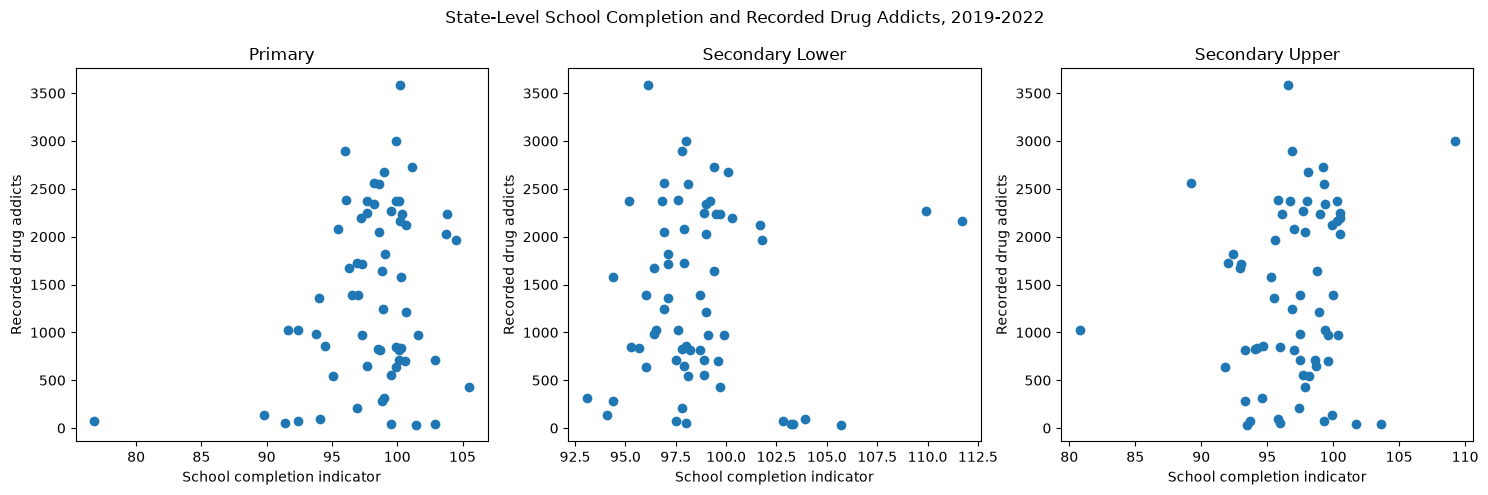

In [22]:
fig, axes = plt.subplots(1, len(completion_stages), figsize=(5 * len(completion_stages), 5))
if len(completion_stages) == 1:
    axes = [axes]

for axis, stage in zip(axes, completion_stages):
    valid = merged[[stage, "total_addicts"]].dropna()
    axis.scatter(valid[stage], valid["total_addicts"])
    axis.set_title(stage.replace("_", " ").title())
    axis.set_xlabel("School completion indicator")
    axis.set_ylabel("Recorded drug addicts")

fig.suptitle(f"State-Level School Completion and Recorded Drug Addicts, {START_YEAR}-{END_YEAR}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "completion_and_addicts_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 22. Key Findings

1. **State distribution:** Kedah had the most recorded addicts over 2019-2022 (10,874 in total; 2,724 in 2022), followed by Kelantan (9,775) and Johor (9,690). The smallest totals were W.P. Putrajaya (197), W.P. Labuan (355) and Perlis (1,239).
2. **State share:** In 2022 the largest `state_share_pct` values were Kedah (11.6%), Johor (11.4%) and Selangor (10.9%). These are shares of administrative records, not per-capita rates.
3. **Educational composition:** SPM (39.1%) and PMR (34.8%) are the most common education categories among recorded addicts over 2019-2022.
4. **Time trend:** The largest year-on-year increase was Perlis (+101.4% in 2022) and the largest decrease was Sabah (-47.0% in 2020). Several states show swings above 60%, so annual totals are volatile.
5. **School completion association:** Pearson correlations with total recorded addicts were weak: primary 0.27, upper secondary 0.15, lower secondary 0.02. These are exploratory state-level associations only and do not show that completion rates affect recorded addiction.
6. **Implications:** The descriptive patterns may inform targeted prevention, education, treatment, or rehabilitation planning, but they do not identify which individuals are at risk and do not stigmatise any state or education group.

## 23. Limitations

1. The drug data contains administrative records and may not include all persons experiencing drug addiction.
2. Recorded drug addiction is not equivalent to a drug offence, arrest, prosecution, or conviction.
3. The drug dataset records the highest education level of recorded individuals, while the school dataset reports state-level completion indicators. These are different statistical concepts.
4. Aggregate state-level relationships cannot be applied directly to individuals. Doing so would risk an ecological fallacy.
5. Raw state counts are affected by population size. Without state population denominators, the results are not per-capita addiction rates.
6. Missing values are retained as unavailable rather than automatically replaced with zero.
7. Completion values above 100 are retained for transparency and should be interpreted according to the source's indicator definition.
8. Correlation does not establish causation. Age, income, employment, urbanisation, service access, enforcement, and reporting practices may affect the observed patterns.
9. The state-level analysis covers 2019-2022: state-level drug records begin in 2019, and the school completion dataset does not include 2023 observations.
10. The supervised prediction part has additional technical and interpretive limitations, described in Section 37.

## 24. Export Processed and Summarised Outputs

In [23]:
state_summary.to_csv(OUTPUT_DIR / "state_addiction_summary.csv", index=False)
education_summary.to_csv(OUTPUT_DIR / "education_addiction_summary.csv", index=False)
state_trends.to_csv(OUTPUT_DIR / "state_addiction_trends.csv", index=False)
dominant_education.to_csv(OUTPUT_DIR / "dominant_education_by_state_year.csv", index=False)
merged.to_csv(OUTPUT_DIR / "merged_addiction_school_completion.csv", index=False)

print("Saved output files:")
for output_file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", output_file)
print("Saved figures:")
for figure_file in sorted(FIGURE_DIR.glob("*.png")):
    print("-", figure_file)

Saved output files:
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\dominant_education_by_state_year.csv
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\education_addiction_summary.csv
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\merged_addiction_school_completion.csv
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\state_addiction_summary.csv
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\state_addiction_trends.csv
Saved figures:
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\completion_and_addicts_scatter.png
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\education_composition.png
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\recorded_addicts_by_state.png
- C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output\selected_state_trends.png
- C:\Users\User\Documents\Gi

## 25. Conclusion

The analysis describes how recorded drug addiction cases vary across Malaysian states, years, and education categories over 2019-2022, and it assesses whether state-level school completion indicators are associated with total recorded counts (the correlations are weak). It then tests whether the following year's recorded total can be predicted from prior-year state-level indicators. On the untouched 2022 holdout, every trained model beat the constant-mean baseline, but none beat the naive "last year's total" benchmark, so the trained models do not support claims of reliable practical forecasting. Conclusions remain descriptive and cautious because the datasets are aggregated administrative records and do not establish individual risk or causation.

# Part 2: Supervised Machine Learning

## 26. Supervised Machine Learning Objective

This part extends the analysis with a supervised regression task that answers the prediction clause of the Research Question: **how accurately can the following year's number of recorded drug addicts in each Malaysian state be predicted using only information available in the preceding year?**

- **What was done:** for each state, the number recorded in year *t* + 1 is treated as the target, and features observed in year *t* are used as predictors.
- **Why:** a lagged design mirrors how forecasting works in practice - only past information is available at the time a forecast is made.
- **What the output means:** holdout errors (MAE, RMSE, R-squared) computed on the untouched 2022 test set.
- **What cannot be concluded:** that education indicators cause changes in recorded addiction, or that the models are reliable for years beyond 2022.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("scikit-learn imports ready.")

scikit-learn imports ready.


## 27. Lagged Feature Construction

A transition-level dataset is built from the state-level records prepared in Part 1. Each row represents one state-year transition:

- 2019 features predict the 2020 total;
- 2020 features predict the 2021 total;
- 2021 features predict the 2022 total.

Every predictor is observed in the **preceding** year. The core numerical predictors are `previous_total_addicts`, `previous_primary_completion`, `previous_secondary_lower_completion`, `previous_secondary_upper_completion` and `feature_year`.

Two deliberate parsimony decisions:

- `previous_state_share_pct` is exported in `ml_modelling_dataset.csv` (as part of the expected dataset structure) but is **excluded from the feature matrix** because it correlates about 0.96 with `previous_total_addicts` in the training period - it is near-redundant, and a collinear extra column adds instability to a small sample.
- The eight previous-year education-category share features are **not added**: with only 32 training rows, extra features increase overfitting risk without evidence that they improve predictions.

With 16 states and 3 transitions the maximum sample size is 48 observations, subject to missing data. The actual count is validated after construction.

In [25]:
TRANSITIONS = [(2019, 2020), (2020, 2021), (2021, 2022)]

ml_rows = []
for feature_year, target_year in TRANSITIONS:
    feature_totals = state_totals[state_totals["year"] == feature_year]
    target_totals = state_totals[state_totals["year"] == target_year]
    feature_school = school_wide[school_wide["year"] == feature_year]
    for _, frow in feature_totals.iterrows():
        state = frow["state"]
        trow = target_totals[target_totals["state"] == state]
        srow = feature_school[feature_school["state"] == state]
        if trow.empty or srow.empty:
            continue
        ml_rows.append({
            "state": state,
            "feature_year": feature_year,
            "target_year": target_year,
            "previous_total_addicts": frow["total_addicts"],
            "previous_state_share_pct": frow["state_share_pct"],
            "previous_primary_completion": srow.iloc[0]["primary"],
            "previous_secondary_lower_completion": srow.iloc[0]["secondary_lower"],
            "previous_secondary_upper_completion": srow.iloc[0]["secondary_upper"],
            "target_total_addicts": trow.iloc[0]["total_addicts"],
        })

ml_data = pd.DataFrame(ml_rows)
ml_data.to_csv(OUTPUT_DIR / "ml_modelling_dataset.csv", index=False)

print("Modelling dataset shape:", ml_data.shape)
print("Missing values in the modelling dataset:", int(ml_data.isna().sum().sum()))
print("Expected maximum sample size: 16 states x 3 transitions = 48")
display(ml_data)

Modelling dataset shape: (48, 9)
Missing values in the modelling dataset: 0
Expected maximum sample size: 16 states x 3 transitions = 48


,state,feature_year,target_year,previous_total_addicts,previous_state_share_pct,previous_primary_completion,previous_secondary_lower_completion,previous_secondary_upper_completion,target_total_addicts
0,Johor,2019,2020,"2,371.00",9.09,97.70,95.20,98.00,"2,564.00"
1,Kedah,2019,2020,"3,582.00",13.73,100.20,96.10,96.60,"2,372.00"
2,Kelantan,2019,2020,"2,998.00",11.50,99.90,98.00,109.20,"2,271.00"
3,Melaka,2019,2020,819.00,3.14,98.70,98.70,97.00,829.00
4,Negeri Sembilan,2019,2020,"1,244.00",4.77,98.90,96.90,96.90,812.00
5,Pahang,2019,2020,"1,672.00",6.41,96.30,96.40,92.90,"1,395.00"
6,Perak,2019,2020,"2,046.00",7.85,98.60,96.90,97.90,"1,821.00"
7,Perlis,2019,2020,316.00,1.21,99.00,93.10,94.60,281.00
8,Pulau Pinang,2019,2020,"2,893.00",11.09,96.00,97.80,96.90,"1,727.00"
9,Sabah,2019,2020,"1,574.00",6.04,100.30,94.40,95.30,834.00


## 28. Data Leakage Prevention

**All predictors were lagged by one year, and no target-year information was included in the feature matrix.**

The following target-year variables are never used as predictors:

- target-year education-category counts;
- target-year education shares;
- target-year state share;
- target-year year-on-year change;
- target-year total addicts;
- any variable calculated using the target value, or any post-target-year value.

In particular, the target year's education-category counts are not used, because those category counts approximately reconstruct the target total and would leak the answer. The code below verifies each condition programmatically and **raises an error if any check fails**.

In [26]:
FEATURE_COLUMNS = [
    "previous_total_addicts",
    "previous_primary_completion",
    "previous_secondary_lower_completion",
    "previous_secondary_upper_completion",
    "feature_year",
]
TARGET_COLUMN = "target_total_addicts"

leakage_checks = {
    "feature_year is always less than target_year":
        bool((ml_data["feature_year"] < ml_data["target_year"]).all()),
    "target_year equals feature_year + 1":
        bool((ml_data["target_year"] == ml_data["feature_year"] + 1).all()),
    "no duplicate state-target_year rows":
        not ml_data.duplicated(["state", "target_year"]).any(),
    "target column is absent from X":
        TARGET_COLUMN not in FEATURE_COLUMNS,
    "no target-year-derived columns are present in X":
        not any("target" in column for column in FEATURE_COLUMNS),
}

for check_name, passed in leakage_checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {check_name}")
    if not passed:
        raise RuntimeError(f"Data leakage check failed: {check_name}")

print("All data leakage checks passed: the feature matrix contains only lagged, prior-year information.")

[PASS] feature_year is always less than target_year
[PASS] target_year equals feature_year + 1
[PASS] no duplicate state-target_year rows
[PASS] target column is absent from X
[PASS] no target-year-derived columns are present in X
All data leakage checks passed: the feature matrix contains only lagged, prior-year information.


## 29. Temporal Train-Test Split

A **random** train-test split is deliberately **not** used: the rows are state-year transitions, so a random split could mix later years into training and would overstate performance.

- **Training observations:** 2019 features predicting 2020, and 2020 features predicting 2021 (expected maximum 32 rows).
- **Test observations:** 2021 features predicting 2022 (expected maximum 16 rows).

The 2022 test targets remain **completely untouched** during model fitting, preprocessing fitting (imputation, scaling, one-hot encoding), model selection, and hyperparameter selection. The actual sizes are validated below after missing-data handling.

In [27]:
TRAIN_FEATURE_YEARS = [2019, 2020]
TEST_FEATURE_YEAR = 2021

train_ml = ml_data[ml_data["feature_year"].isin(TRAIN_FEATURE_YEARS)].copy()
test_ml = ml_data[ml_data["feature_year"] == TEST_FEATURE_YEAR].copy()

X_train = train_ml[FEATURE_COLUMNS]
y_train = train_ml[TARGET_COLUMN]
X_test = test_ml[FEATURE_COLUMNS]
y_test = test_ml[TARGET_COLUMN]
train_states = train_ml["state"].to_numpy()

print("Training observations:", len(train_ml))
print("Test observations:", len(test_ml))
print("Training states:", train_ml["state"].nunique())
print("Test states:", test_ml["state"].nunique())
print("Feature names (Configuration A):", FEATURE_COLUMNS)
print("Feature names (Configuration B):", FEATURE_COLUMNS + ["state (one-hot encoded)"])

assert len(train_ml) == 32, f"Expected 32 training observations, got {len(train_ml)}"
assert len(test_ml) == 16, f"Expected 16 test observations, got {len(test_ml)}"
assert set(test_ml["state"]) <= set(train_ml["state"]), "All test states must appear in training"
print("Train/test sizes validated.")

Training observations: 32
Test observations: 16
Training states: 16
Test states: 16
Feature names (Configuration A): ['previous_total_addicts', 'previous_primary_completion', 'previous_secondary_lower_completion', 'previous_secondary_upper_completion', 'feature_year']
Feature names (Configuration B): ['previous_total_addicts', 'previous_primary_completion', 'previous_secondary_lower_completion', 'previous_secondary_upper_completion', 'feature_year', 'state (one-hot encoded)']
Train/test sizes validated.


## 30. Baseline Models

Two baselines are evaluated on the untouched 2022 holdout:

1. **DummyRegressor with a mean strategy** - predicts the mean of the training-period targets (1,214.0) for every state. This is the statistical baseline: a trained model is useful only if it beats it on the holdout.
2. **Naive previous-year baseline** - predicts next year's total as equal to the previous year's total. This is not a trained model, but it is the practical benchmark that a planner could use without any model: "assume next year is the same as this year".

Why both: the mean baseline tests whether the features carry any predictive signal at all; the naive baseline tests whether a trained model adds anything over simply carrying the last count forward. Because annual state totals are volatile, the naive benchmark is expected to be strong.

In [28]:
mean_baseline = DummyRegressor(strategy="mean")
mean_baseline.fit(X_train, y_train)

naive_pred_test = test_ml["previous_total_addicts"].to_numpy()

print("DummyRegressor (mean) predicts the training-period mean:", round(float(mean_baseline.constant_[0]), 1))
print("Naive previous-year baseline: 2022 prediction = 2021 total for each state.")
print("Naive predictions (first 5):", naive_pred_test[:5])

DummyRegressor (mean) predicts the training-period mean: 1214.0
Naive previous-year baseline: 2022 prediction = 2021 total for each state.
Naive predictions (first 5): [2081. 2196. 2167.  539.  709.]


## 31. Linear Regression

Ordinary least squares (OLS) is applied through a scikit-learn **Pipeline** with a **ColumnTransformer**:

- missing numeric values are imputed with the median (**fitted on training data only**);
- numeric features are standardised with `StandardScaler` (addict counts, completion percentages and year values are on very different scales, so standardisation makes coefficients comparable and helps the solver);
- the imputer and scaler are never refitted on the test set.

Two feature configurations are run:

- **Configuration A:** historical numerical indicators only (no state identity).
- **Configuration B:** the same indicators **plus** one-hot-encoded state (`OneHotEncoder(handle_unknown="ignore")`).

Why Configuration B: state identity may capture persistent state-level differences (for example, reporting intensity or detection coverage). Why it may mislead: the same 16 states appear in both training and testing, so the state dummies may partly **memorise each state's typical scale** rather than learn transferable patterns. The honest judgement is the untouched 2022 holdout.

In [29]:
numeric_preprocessor = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor_a = ColumnTransformer([
    ("numeric", numeric_preprocessor, FEATURE_COLUMNS),
])
preprocessor_b = ColumnTransformer([
    ("numeric", numeric_preprocessor, FEATURE_COLUMNS),
    ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
])

X_train_b = train_ml[FEATURE_COLUMNS + ["state"]]
X_test_b = test_ml[FEATURE_COLUMNS + ["state"]]

linear_a = Pipeline([("prep", preprocessor_a), ("model", LinearRegression())])
linear_b = Pipeline([("prep", preprocessor_b), ("model", LinearRegression())])
linear_a.fit(X_train, y_train)
linear_b.fit(X_train_b, y_train)

print("LinearRegression (Config A) fitted on", len(X_train), "training rows.")
print("LinearRegression (Config B) fitted on", len(X_train_b), "training rows with one-hot state columns.")
print("Config B transformed feature count:", linear_b.named_steps["prep"].transform(X_train_b).shape[1])

LinearRegression (Config A) fitted on 32 training rows.
LinearRegression (Config B) fitted on 32 training rows with one-hot state columns.
Config B transformed feature count: 21


## 32. Ridge Regression

Ridge adds L2 shrinkage to the linear model, which stabilises coefficients when predictors are correlated and the sample is small (as here).

- **Alpha selection:** a small, explicit candidate grid `[0.01, 0.1, 1.0, 10.0, 100.0]`, evaluated with cross-validation **on the training period only**.
- **Cross-validation strategy:** `GroupKFold` with 8 splits, **grouped by state**. With a plain random split the same state could appear in both the training and validation folds, making validation optimistic; grouping by state keeps each state on one side of every fold. The 2022 holdout observations are never part of this cross-validation.
- The final model is refitted on the full training period with the selected alpha.

In [30]:
alpha_grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
grouped_cv = GroupKFold(n_splits=8)

ridge_gs_a = GridSearchCV(
    Pipeline([("prep", preprocessor_a), ("model", Ridge())]),
    alpha_grid, cv=grouped_cv, scoring="neg_mean_absolute_error",
)
ridge_gs_a.fit(X_train, y_train, groups=train_states)
ridge_a = ridge_gs_a.best_estimator_

ridge_gs_b = GridSearchCV(
    Pipeline([("prep", preprocessor_b), ("model", Ridge())]),
    alpha_grid, cv=grouped_cv, scoring="neg_mean_absolute_error",
)
ridge_gs_b.fit(X_train_b, y_train, groups=train_states)
ridge_b = ridge_gs_b.best_estimator_

print("Ridge (Config A): selected alpha =", ridge_gs_a.best_params_["model__alpha"],
      "| grouped-CV MAE =", round(-ridge_gs_a.best_score_, 1))
print("Ridge (Config B): selected alpha =", ridge_gs_b.best_params_["model__alpha"],
      "| grouped-CV MAE =", round(-ridge_gs_b.best_score_, 1))
print("The 2022 holdout targets were not used in either selection.")

Ridge (Config A): selected alpha = 0.01 | grouped-CV MAE = 244.9
Ridge (Config B): selected alpha = 1.0 | grouped-CV MAE = 297.2
The 2022 holdout targets were not used in either selection.


## 33. Optional Random Forest

A Random Forest regressor was considered and **deliberately not included**.

- The training sample contains only 32 observations - far too few for an ensemble model to learn the non-linear interactions that justify it.
- Shallow trees would still risk memorising the two training transitions, and the tree-specific hyperparameters would add a second tuning dimension to a dataset where the linear models already absorb the available signal.
- The comparison of the mean baseline, the naive previous-year baseline, LinearRegression and Ridge already answers the prediction clause of the Research Question; adding Random Forest would complicate the notebook without a principled benefit at this sample size.

This decision keeps the modelling parsimonious, as required for a small dataset.

## 34. Model Evaluation

Every baseline and trained model is evaluated on the **untouched 2022 holdout set** using:

- **MAE** - mean absolute error, in number of recorded addicts;
- **RMSE** - root mean squared error, computed as the square root of the mean squared error (a version-safe calculation);
- **R-squared** - coefficient of determination on the holdout; **a negative holdout R-squared means the model performed worse than a constant-mean benchmark on that holdout data**.

Model selection uses holdout MAE and RMSE primarily, with R-squared and the baselines as context. Lower error is better.

In [31]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

evaluated_models = [
    ("DummyRegressor (mean)", mean_baseline, X_test),
    ("Naive previous-year", None, None),
    ("LinearRegression (Config A)", linear_a, X_test),
    ("LinearRegression (Config B)", linear_b, X_test_b),
    ("Ridge (Config A)", ridge_a, X_test),
    ("Ridge (Config B)", ridge_b, X_test_b),
]

evaluation_results = []
predictions_by_model = {}
for model_name, model, x_test_used in evaluated_models:
    if model_name == "Naive previous-year":
        predicted = naive_pred_test
    else:
        predicted = model.predict(x_test_used)
    predictions_by_model[model_name] = predicted
    evaluation_results.append({
        "model": model_name,
        "mae": mean_absolute_error(y_test, predicted),
        "rmse": rmse(y_test, predicted),
        "r_squared": r2_score(y_test, predicted),
    })

evaluation_df = pd.DataFrame(evaluation_results).sort_values("mae")
evaluation_df = evaluation_df.round(2)
evaluation_df.to_csv(OUTPUT_DIR / "model_evaluation_results.csv", index=False)

print("Model evaluation on the untouched 2022 holdout set (sorted by MAE):")
display(evaluation_df)
print("2022 holdout target mean:", round(float(y_test.mean()), 1),
      "(the mean baseline predicts the training-period mean, 1,214.0)")

Model evaluation on the untouched 2022 holdout set (sorted by MAE):


,model,mae,rmse,r_squared
1,Naive previous-year,335.12,429.10,0.79
5,Ridge (Config B),344.40,475.54,0.74
2,LinearRegression (Config A),382.27,483.97,0.73
4,Ridge (Config A),382.40,484.16,0.73
3,LinearRegression (Config B),615.22,682.00,0.47
0,DummyRegressor (mean),848.06,969.76,-0.07


2022 holdout target mean: 1469.8 (the mean baseline predicts the training-period mean, 1,214.0)


## 35. Best-Model Selection

Actual holdout results (16 states, 2022):

- **Lowest holdout MAE:** the naive previous-year baseline (335.1). Among trained models, Ridge (Config B) is best (344.4).
- **Lowest holdout RMSE:** the naive previous-year baseline (429.1). Among trained models, Ridge (Config B) is best (475.5).
- **Holdout R-squared:** naive 0.79, Ridge B 0.74, Ridge A and LinearRegression A 0.73, LinearRegression B 0.47, DummyRegressor -0.07.

Interpretation:

- **All trained models outperform the mean baseline** (MAE 382-615 versus 848), so the lagged features do carry signal - especially the previous year's own total.
- **No trained model outperforms the naive previous-year baseline** on any holdout metric. The naive benchmark has the lowest MAE and RMSE; its R-squared (0.79) is also the highest.
- The dummy's slightly negative R-squared (-0.07) reflects that the training-period mean (1,214.0) is lower than the 2022 holdout mean (about 1,470), so a constant prediction performs a little worse than a constant-mean benchmark computed on the holdout itself.
- LinearRegression (Config B) performs markedly worse (MAE 615.2) and even produced a negative prediction (about -1,157) for W.P. Putrajaya - evidence that one-hot state dummies partly memorise state scale and destabilise extrapolation for the smallest states.

**Conclusion:** by the rule that a model is useful only if it improves on the relevant baselines, no trained model is clearly useful for this task. Ridge (Config B) is the best trained model, but it does not beat carrying the previous year's total forward, so **the results do not support practical forecasting** claims.

## 36. Prediction Error Analysis

For the 2022 holdout, `prediction_error = predicted total - actual total`; a positive error is an **overprediction** and a negative error is an **underprediction**. Predictions for every model are saved to `state_predictions_2022.csv`. The error figures use **Ridge (Config B)**, the best trained model.

In [32]:
prediction_rows = []
for model_name, predicted in predictions_by_model.items():
    for idx, state in enumerate(test_ml["state"].to_numpy()):
        actual = float(y_test.iloc[idx])
        pred = float(predicted[idx])
        prediction_rows.append({
            "state": state,
            "target_year": int(test_ml["target_year"].iloc[idx]),
            "actual_total_addicts": actual,
            "predicted_total_addicts": pred,
            "prediction_error": pred - actual,
            "absolute_error": abs(pred - actual),
            "model": model_name,
        })

state_predictions = pd.DataFrame(prediction_rows)
state_predictions.to_csv(OUTPUT_DIR / "state_predictions_2022.csv", index=False)
print("state_predictions_2022.csv rows:", len(state_predictions))
display(state_predictions[state_predictions["model"] == "Ridge (Config B)"])

state_predictions_2022.csv rows: 96


,state,target_year,actual_total_addicts,predicted_total_addicts,prediction_error,absolute_error,model
80,Johor,2022,"2,674.00","2,069.75",-604.25,604.25,Ridge (Config B)
81,Kedah,2022,"2,724.00","1,936.84",-787.16,787.16,Ridge (Config B)
82,Kelantan,2022,"2,339.00","2,080.75",-258.25,258.25,Ridge (Config B)
83,Melaka,2022,555.00,664.38,109.38,109.38,Ridge (Config B)
84,Negeri Sembilan,2022,969.00,805.47,-163.53,163.53,Ridge (Config B)
85,Pahang,2022,"1,392.00","1,041.17",-350.83,350.83,Ridge (Config B)
86,Perak,2022,"2,376.00","1,651.04",-724.96,724.96,Ridge (Config B)
87,Perlis,2022,429.00,433.82,4.82,4.82,Ridge (Config B)
88,Pulau Pinang,2022,"2,247.00","1,101.03","-1,145.97","1,145.97",Ridge (Config B)
89,Sabah,2022,703.00,645.58,-57.42,57.42,Ridge (Config B)


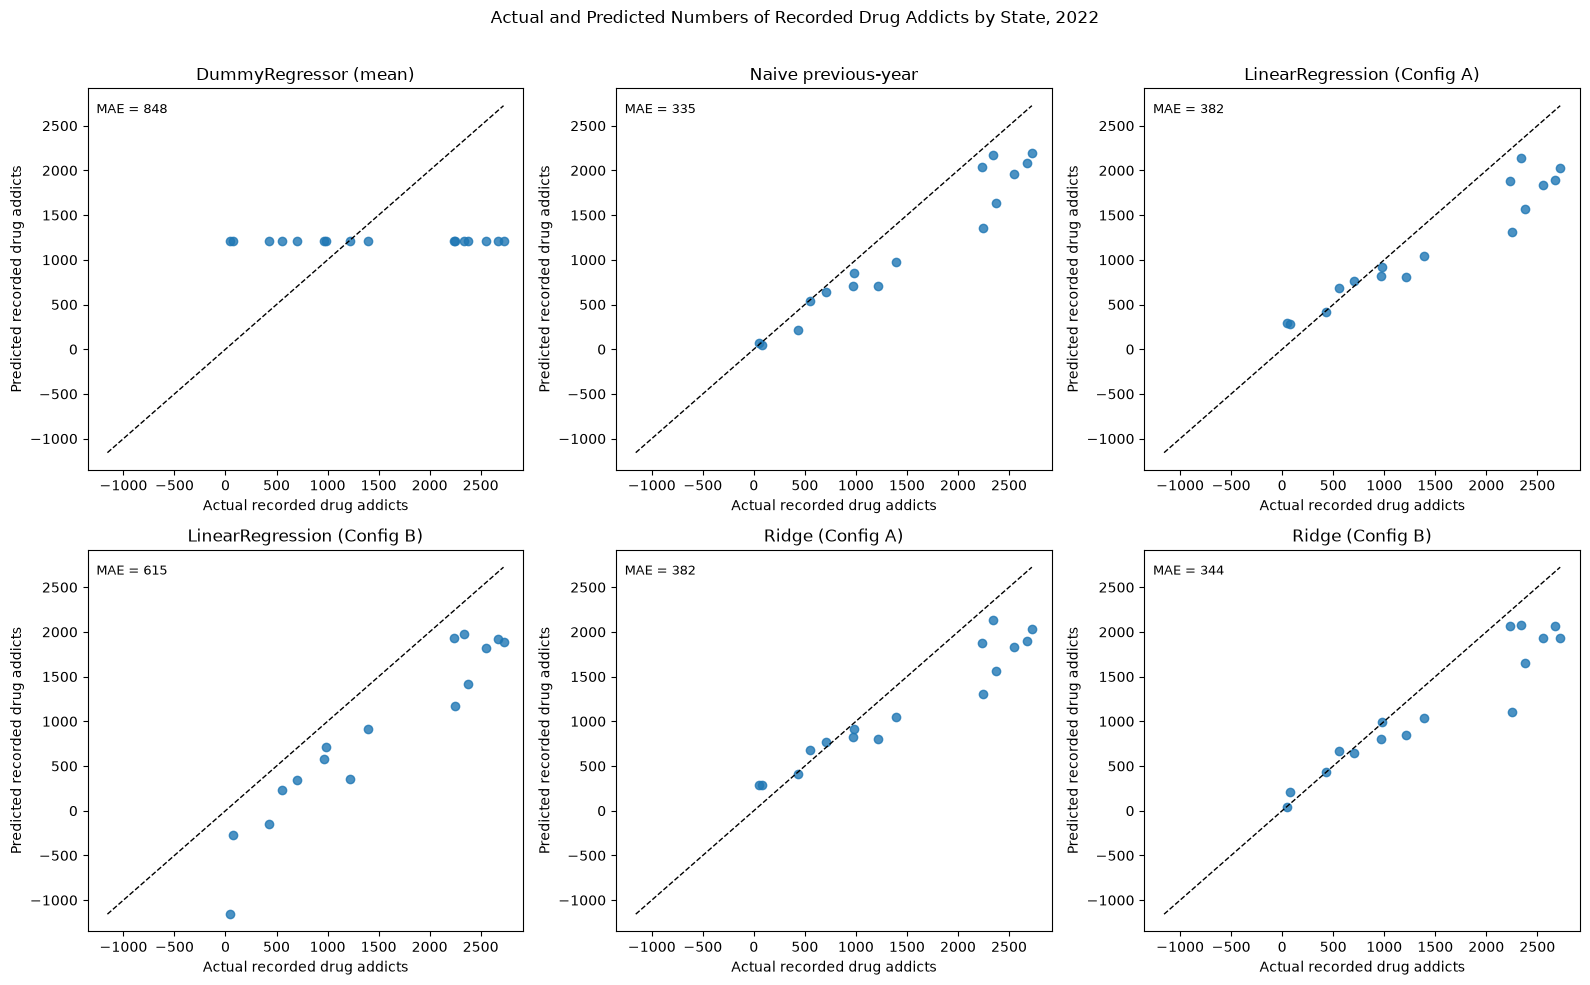

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
all_values = np.concatenate([y_test.to_numpy()] + [p for p in predictions_by_model.values()])
plot_min, plot_max = float(all_values.min()), float(all_values.max())
plot_min = min(plot_min, 0.0)
padding = (plot_max - plot_min) * 0.05

for axis, (model_name, predicted) in zip(axes.ravel(), predictions_by_model.items()):
    axis.scatter(y_test, predicted, alpha=0.8)
    axis.plot([plot_min, plot_max], [plot_min, plot_max], "k--", linewidth=1)
    axis.set_xlim(plot_min - padding, plot_max + padding)
    axis.set_ylim(plot_min - padding, plot_max + padding)
    axis.set_title(model_name)
    axis.set_xlabel("Actual recorded drug addicts")
    axis.set_ylabel("Predicted recorded drug addicts")
    axis.text(0.02, 0.96,
              f"MAE = {mean_absolute_error(y_test, predicted):,.0f}",
              transform=axis.transAxes, va="top", fontsize=9)

fig.suptitle("Actual and Predicted Numbers of Recorded Drug Addicts by State, 2022")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURE_DIR / "actual_vs_predicted_2022.png", dpi=300, bbox_inches="tight")
plt.show()

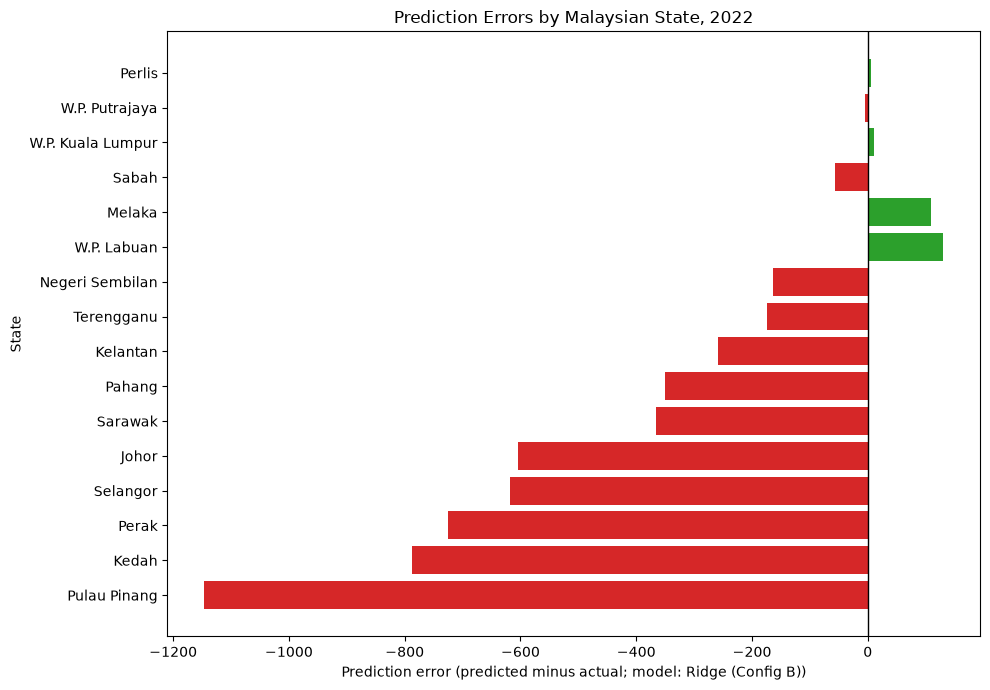

Largest absolute errors (Ridge, Config B):
       state  prediction_error  absolute_error
Pulau Pinang         -1,145.97        1,145.97
       Kedah           -787.16          787.16
       Perak           -724.96          724.96
    Selangor           -617.79          617.79
       Johor           -604.25          604.25
Overpredicted states: ['Melaka', 'Perlis', 'W.P. Kuala Lumpur', 'W.P. Labuan']
Underpredicted states: ['Johor', 'Kedah', 'Kelantan', 'Negeri Sembilan', 'Pahang', 'Perak', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Putrajaya']


In [34]:
best_model_name = "Ridge (Config B)"
best_pred = predictions_by_model[best_model_name]
best_error = pd.DataFrame({
    "state": test_ml["state"].to_numpy(),
    "prediction_error": best_pred - y_test.to_numpy(),
    "absolute_error": np.abs(best_pred - y_test.to_numpy()),
}).sort_values("absolute_error", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colours = ["#d62728" if error < 0 else "#2ca02c" for error in best_error["prediction_error"]]
ax.barh(best_error["state"], best_error["prediction_error"], color=colours)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Prediction Errors by Malaysian State, 2022")
ax.set_xlabel(f"Prediction error (predicted minus actual; model: {best_model_name})")
ax.set_ylabel("State")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "prediction_errors_by_state_2022.png", dpi=300, bbox_inches="tight")
plt.show()

print("Largest absolute errors (Ridge, Config B):")
print(best_error.head(5).to_string(index=False))
print("Overpredicted states:", sorted(best_error.loc[best_error["prediction_error"] > 0, "state"]))
print("Underpredicted states:", sorted(best_error.loc[best_error["prediction_error"] < 0, "state"]))

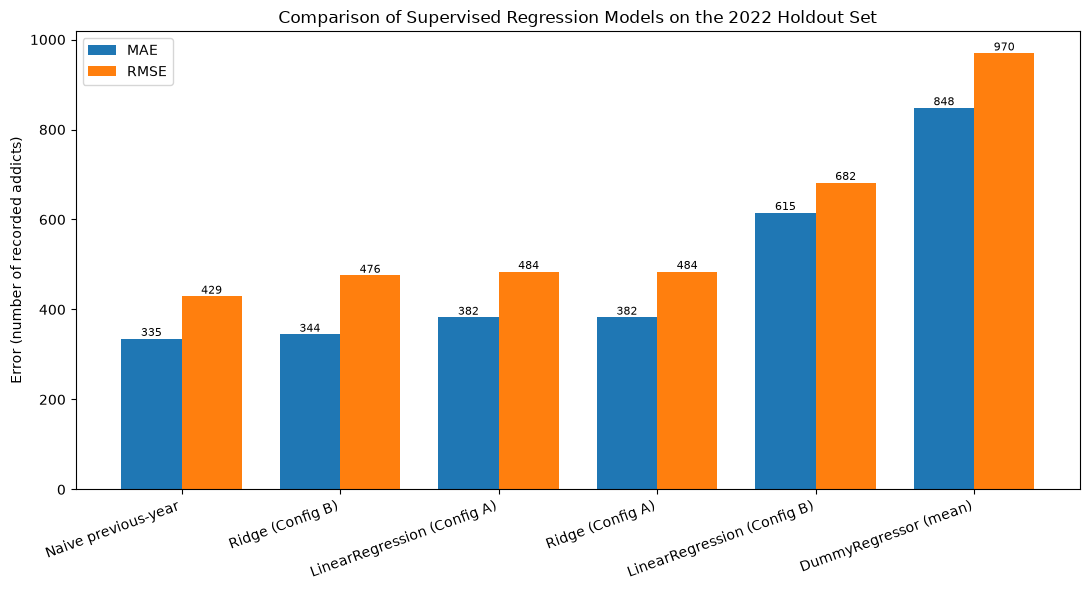

In [35]:
fig, ax = plt.subplots(figsize=(11, 6))
x_positions = np.arange(len(evaluation_df))
width = 0.38
mae_bars = ax.bar(x_positions - width / 2, evaluation_df["mae"], width,
                  label="MAE", color="#1f77b4")
rmse_bars = ax.bar(x_positions + width / 2, evaluation_df["rmse"], width,
                   label="RMSE", color="#ff7f0e")

for bar in list(mae_bars) + list(rmse_bars):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(evaluation_df["model"], rotation=20, ha="right")
ax.set_ylabel("Error (number of recorded addicts)")
ax.set_title("Comparison of Supervised Regression Models on the 2022 Holdout Set")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 37. Machine Learning Limitations

1. **Small sample:** only 32 training and 16 test observations from a four-year administrative series; every metric is an estimate with wide uncertainty.
2. **Single temporal holdout:** the 2022 evaluation is one draw. With so few years, no repeated or rolling evaluation is possible, so the results could be specific to 2022.
3. **Non-independent observations:** state-year transitions are autocorrelated - adjacent years of the same state resemble each other - so the effective information content is smaller than the row count suggests.
4. **Volatile administrative totals:** year-on-year swings above 60% (for example Perlis +101.4% in 2022) make any model's task hard; the trained models did not beat the naive "last year's total" benchmark.
5. **State dummies in Configuration B** may memorise each state's scale during training rather than learn transferable patterns, and LinearRegression (Config B) produced an impossible negative prediction for W.P. Putrajaya.
6. **No causal interpretation:** a predictive association between lagged indicators and the following year's total does not imply that education indicators influence recorded addiction.
7. **Completion values above 100** are retained as flagged; their interpretation depends on official source metadata, and no explanation is invented here.
8. **Scope of validity:** all results describe 2019-2022 administrative records; they do not demonstrate that forecasting works in other years, other countries, or other record systems.

In [36]:
required_outputs = [
    "ml_modelling_dataset.csv",
    "model_evaluation_results.csv",
    "state_predictions_2022.csv",
    "actual_vs_predicted_2022.png",
    "prediction_errors_by_state_2022.png",
    "model_comparison.png",
]
missing_outputs = [name for name in required_outputs if not (OUTPUT_DIR / name).exists()]
if missing_outputs:
    raise FileNotFoundError(f"Missing output files: {missing_outputs}")

print("All required machine learning outputs exist in", OUTPUT_DIR.resolve())
for name in required_outputs:
    print("-", name)

All required machine learning outputs exist in C:\Users\User\Documents\GitHub\BTPR3203-Final-Assessment-Group2\output
- ml_modelling_dataset.csv
- model_evaluation_results.csv
- state_predictions_2022.csv
- actual_vs_predicted_2022.png
- prediction_errors_by_state_2022.png
- model_comparison.png
